### Two-body simulation with post-Newtonian correction up to 3.5 terms integrated with Runge-Kutta 4 integrator to simulate the inspiral of binary black hole merger events

In [2]:
import math
import numpy as np
import scipy.constants as const
import matplotlib.pyplot as plt
G_SI = const.G
pi2 = np.pi**2
pi = np.pi
c_SI = const.c

In [3]:
def si_to_geom(m):
    return G_SI * m / c_SI**2

In [4]:
G = 1.0
c = 1.0

## 0PN

In [6]:
def a_0(m1, m2, v1, v2, r12, n12, n12v1, n12v2, v12, v21, v1v2, n12v12, r1p, r2p, ln1, ln2):
    return -(G*m2*n12)/r12**2

## 1PN $(1/c^2)$

In [8]:
def a_1(m1, m2, v1, v2, r12, n12, n12v1, n12v2, v12, v21, v1v2, n12v12, r1p, r2p, ln1, ln2):
    return (1/c**2)*((
        (5*G**2*m1*m2/r12**3)
        + (4*G**2*m2**2/r12**3)
        + (G*m2/r12**2)*(
            (3/2)*n12v2**2
            - v1**2
            + 4*v1v2
            - 2*v2**2
        )
    ) * n12
    + (
        (G*m2/r12**2)*(4*n12v1 - 3*n12v2)
    ) * v12)

## 2PN $(1/c^4)$

In [10]:
def a_2(m1, m2, v1, v2, r12, n12, n12v1, n12v2, v12, v21, v1v2, n12v12, r1p, r2p, ln1, ln2):
    return (1/c**4)*((
        (-57*G**3*m1**2*m2/(4*r12**4))
        - (69*G**3*m1*m2**2/(2*r12**4))
        - (9*G**3*m2**3/r12**4)
        + (G*m2/r12**2)*(
            (-15/8)*n12v2**4
            + (3/2)*n12v2**2*v1**2
            - 6*n12v2**2*v1v2
            - 2*v1v2**2
            + (9/2)*n12v2**2*v2**2
            + 4*v1v2*v2**2
            - 2*v2**4
        )
        + (G**2*m1*m2/r12**3)*(
            (39/2)*n12v1**2
            - 39*n12v1*n12v2
            + (17/2)*n12v2**2
            - (15/4)*v1**2
            - (5/2)*v1v2
            + (5/4)*v2**2
        )
        + (G**2*m2**2/r12**3)*(
            2*n12v1**2
            - 4*n12v1*n12v2
            - 6*n12v2**2
            - 8*v1v2
            + 4*v2**2
        )
    ) * n12
    + (
        (G**2*m2**2/r12**3)*(-2*n12v1 - 2*n12v2)
        + (G**2*m1*m2/r12**3)*((-63/4)*n12v1 + (55/4)*n12v2)
        + (G*m2/r12**2)*(
            -6*n12v1*n12v2**2
            + (9/2)*n12v2**3
            + n12v2*v1**2
            - 4*n12v1*v1v2
            + 4*n12v2*v1v2
            + 4*n12v1*v2**2
            - 5*n12v2*v2**2
        )
    ) * v12)

## 2.5PN $(1/c^5)$

In [12]:
def a_2p5(m1, m2, v1, v2, r12, n12, n12v1, n12v2, v12, v21, v1v2, n12v12, r1p, r2p, ln1, ln2):
    return (1/c**5)*((
        (208*G**3*m1*m2**2/(15*r12**4))*n12v12
        - (24*G**3*m1**2*m2/(5*r12**4))*n12v12
        + (12*G**2*m1*m2/(5*r12**3))*n12v12*v12**2
    ) * n12
    + (
        (8*G**3*m1**2*m2/(5*r12**4))
        - (32*G**3*m1*m2**2/(5*r12**4))
        - (4*G**2*m1*m2/(5*r12**3))*v12**2
    ) * v12)

## 3PN $(1/c^6)$

In [21]:
def a_3(m1, m2, v1, v2, r12, n12, n12v1, n12v2, v12, v21, v1v2, n12v12, r1p, r2p, ln1, ln2):
    return (1/c**6)*((
        (G*m2/r12**2)*(
            (35/16)*n12v2**6 - (15/8)*n12v2**4*v1**2 + (15/2)*n12v2**4*v1v2
            + 3*n12v2**2*v1v2**2 - (15/2)*n12v2**4*v2**2 + (3/2)*n12v2**2*v1**2*v2**2
            - 12*n12v2**2*v1v2*v2**2 - 2*v1v2**2*v2**2 + (15/2)*n12v2**2*v2**4
            + 4*v1v2*v2**4 - 2*v2**6
        )
        + (G**2*m1*m2/r12**3)*(
            -(171/8)*n12v1**4 + (171/2)*n12v1**3*n12v2 - (723/4)*n12v1**2*n12v2**2
            + (383/2)*n12v1*n12v2**3 - (455/8)*n12v2**4 + (229/4)*n12v1**2*v1**2
            - (205/2)*n12v1*n12v2*v1**2 + (191/4)*n12v2**2*v1**2 - (91/8)*v1**4
            - (229/2)*n12v1**2*v1v2 + 244*n12v1*n12v2*v1v2 - (225/2)*n12v2**2*v1v2
            + (91/2)*v1**2*v1v2 - (177/4)*v1v2**2 + (229/4)*n12v1**2*v2**2
            - (283/2)*n12v1*n12v2*v2**2 + (259/4)*n12v2**2*v2**2 - (91/4)*v1**2*v2**2
            + 43*v1v2*v2**2 - (81/8)*v2**4
        )
        + (G**2*m2**2/r12**3)*(
            -6*n12v1**2*n12v2**2 + 12*n12v1*n12v2**3 + 6*n12v2**4
            + 4*n12v1*n12v2*v1v2 + 12*n12v2**2*v1v2 + 4*v1v2**2
            - 4*n12v1*n12v2*v2**2 - 12*n12v2**2*v2**2 - 8*v1v2*v2**2 + 4*v2**4
        )
        + (G**3*m2**3/r12**4)*(
            -n12v1**2 + 2*n12v1*n12v2 + (43/2)*n12v2**2 + 18*v1v2 - 9*v2**2
        )
        + (G**3*m1*m2**2/r12**4)*(
            (415/8)*n12v1**2 - (375/4)*n12v1*n12v2 + (1113/8)*n12v2**2
            - (615/64)*n12v12**2*pi2 + 18*v1**2 + (123/64)*pi2*v12**2
            + 33*v1v2 - (33/2)*v2**2
        )
        + (G**3*m1**2*m2/r12**4)*(
            -(45887/168)*n12v1**2 + (24025/42)*n12v1*n12v2 - (10469/42)*n12v2**2
            + (48197/840)*v1**2 - (36227/420)*v1v2 + (36227/840)*v2**2
            + 110*n12v12**2*ln1 - 22*v12**2*ln1
        )
        + 16*G**4*m2**4/r12**5
        + (G**4*m1**2*m2**2/r12**5)*(175 - (41/16)*pi2)
        + (G**4*m1**3*m2/r12**5)*(-(3187/1260) + (44/3)*ln1)
        + (G**4*m1*m2**3/r12**5)*((110741/630) - (41/16)*pi2 - (44/3)*ln2)
    ) * n12
    + (
        (G*m2/r12**2)*(
            (15/2)*n12v1*n12v2**4 - (45/8)*n12v2**5 - (3/2)*n12v2**3*v1**2
            + 6*n12v1*n12v2**2*v1v2 - 6*n12v2**3*v1v2 - 2*n12v2*v1v2**2
            - 12*n12v1*n12v2**2*v2**2 + 12*n12v2**3*v2**2 + n12v2*v1**2*v2**2
            - 4*n12v1*v1v2*v2**2 + 8*n12v2*v1v2*v2**2 + 4*n12v1*v2**4 - 7*n12v2*v2**4
        )
        + (G**2*m2**2/r12**3)*(
            -2*n12v1**2*n12v2 + 8*n12v1*n12v2**2 + 2*n12v2**3
            + 2*n12v1*v1v2 + 4*n12v2*v1v2 - 2*n12v1*v2**2 - 4*n12v2*v2**2
        )
        + (G**2*m1*m2/r12**3)*(
            -(243/4)*n12v1**3 + (565/4)*n12v1**2*n12v2 - (269/4)*n12v1*n12v2**2
            - (95/12)*n12v2**3 + (207/8)*n12v1*v1**2 - (137/8)*n12v2*v1**2
            - 36*n12v1*v1v2 + (27/4)*n12v2*v1v2 + (81/8)*n12v1*v2**2 + (83/8)*n12v2*v2**2
        )
        + (G**3*m2**3/r12**4)*(4*n12v1 + 5*n12v2)
        + (G**3*m1*m2**2/r12**4)*(
            -(307/8)*n12v1 + (479/8)*n12v2 + (123/32)*n12v12*pi2
        )
        + (G**3*m1**2*m2/r12**4)*(
            (31397/420)*n12v1 - (36227/420)*n12v2 - 44*n12v12*ln1
        )
    ) * v12)

## 3.5PN $(1/c^7)$

In [23]:
def a_3p5(m1, m2, v1, v2, r12, n12, n12v1, n12v2, v12, v21, v1v2, n12v12, r1p, r2p, ln1, ln2):
    return (1/c**7)*((
        (G**4*m1**3*m2/r12**5)*(3992/105*n12v1 - 4328/105*n12v2)
        + (G**4*m1**2*m2**2/r12**6)*(-13576/105*n12v1 + 2872/21*n12v2)
        - (3172/21)*(G**4*m1*m2**3/r12**6)*n12v12
        + (G**3*m1**2*m2/r12**4)*(
            48*n12v1**3 - (696/5)*n12v1**2*n12v2 + (744/5)*n12v1*n12v2**2 - (288/5)*n12v2**3
            - (4888/105)*n12v1*v1**2 + (5056/105)*n12v2*v1**2
            + (2056/21)*n12v1*v1v2 - (2224/21)*n12v2*v1v2
            - (1028/21)*n12v1*v2**2 + (5812/105)*n12v2*v2**2
        )
        + (G**3*m1*m2**2/r12**4)*(
            -(582/5)*n12v1**3 + (1746/5)*n12v1**2*n12v2 - (1954/5)*n12v1*n12v2**2 + 158*n12v2**3
            + (3568/105)*n12v12*v1**2
            - (2864/35)*n12v1*v1v2 + (10048/105)*n12v2*v1v2
            + (1432/35)*n12v1*v2**2 - (5752/105)*n12v2*v2**2
        )
        + (G**2*m1*m2/r12**3)*(
            -56*n12v12**5
            + 60*n12v1**3*v12**2 - 180*n12v1**2*n12v2*v12**2
            + 174*n12v1*n12v2**2*v12**2 - 54*n12v2**3*v12**2
            - (246/35)*n12v12*v1**4
            + (1068/35)*n12v1*v1**2*v1v2 - (984/35)*n12v2*v1**2*v1v2
            - (1068/35)*n12v1*v1v2**2 + (180/7)*n12v2*v1v2**2
            - (534/35)*n12v1*v1**2*v2**2 + (90/7)*n12v2*v1**2*v2**2
            + (984/35)*n12v1*v1v2*v2**2 - (732/35)*n12v2*v1v2*v2**2
            - (204/35)*n12v1*v2**4 + (24/7)*n12v2*v2**4
        )
    ) * n12
    + (
        -(184/21)*(G**4*m1**3*m2/r12**5)
        + (6224/105)*(G**4*m1**2*m2**2/r12**6)
        + (6388/105)*(G**4*m1*m2**3/r12**6)
        + (G**3*m1**2*m2/r12**4)*(
            (52/15)*n12v1**2 - (56/15)*n12v1*n12v2 - (44/15)*n12v2**2
            - (132/15)*v1**2 + (152/35)*v1v2 - (48/35)*v2**2
        )
        + (G**3*m1*m2**2/r12**4)*(
            (454/15)*n12v1**2 - (372/5)*n12v1*n12v2 + (854/15)*n12v2**2
            - (152/21)*v1**2 + (2864/105)*v1v2 - (1768/105)*v2**2
        )
        + (G**2*m1*m2/r12**3)*(
            60*n12v12**4
            - (348/5)*n12v1**2*v12**2 + (684/5)*n12v1*n12v2*v12**2 - 66*n12v2**2*v12**2
            + (334/35)*v1**4 - (1336/35)*v1**2*v1v2 + (1308/35)*v1v2**2
            + (654/35)*v1**2*v2**2 - (1252/35)*v1v2*v2**2 + (292/35)*v2**4
        )
    ) * v12)

## Acceleration combined

In [78]:
def a(m1, m2, v1, v2, r12, n12, n12v1, n12v2, v12, v21, v1v2, n12v12, r1p, r2p, ln1, ln2):
    PNa_0 = a_0(m1, m2, v1, v2, r12, n12, n12v1, n12v2, v12, v21, v1v2, n12v12, r1p, r2p, ln1, ln2)
    PNa_1 = a_1(m1, m2, v1, v2, r12, n12, n12v1, n12v2, v12, v21, v1v2, n12v12, r1p, r2p, ln1, ln2)
    PNa_2 = a_2(m1, m2, v1, v2, r12, n12, n12v1, n12v2, v12, v21, v1v2, n12v12, r1p, r2p, ln1, ln2)
    PNa_2p5 = a_2p5(m1, m2, v1, v2, r12, n12, n12v1, n12v2, v12, v21, v1v2, n12v12, r1p, r2p, ln1, ln2)
    PNa_3 = a_3(m1, m2, v1, v2, r12, n12, n12v1, n12v2, v12, v21, v1v2, n12v12, r1p, r2p, ln1, ln2)
    PNa_3p5 = a_3p5(m1, m2, v1, v2, r12, n12, n12v1, n12v2, v12, v21, v1v2, n12v12, r1p, r2p, ln1, ln2)
    return PNa_0 + PNa_1 + PNa_2 + PNa_2p5 + PNa_3 + PNa_3p5

In [80]:
def accelerations(m1, m2, p1, p2, v1, v2, r):
    r12 = np.linalg.norm(p1 - p2)
    r21 = np.linalg.norm(p2 - p1)
    n12 = (p1 - p2) / r12
    n21 = (p2 - p1) / r21
    
    n12v1 = np.dot(n12, v1)
    n12v2 = np.dot(n12, v2)
    n21v1 = np.dot(n21, v1)
    n21v2 = np.dot(n21, v2)
    
    v12 = v1 - v2
    v21 = v2 - v1
    v1v2 = np.dot(v1, v2)
    
    n12v12 = np.dot(n12, v12)
    n21v21 = np.dot(n21, v21)
    
    r1p = r2p = r
    ln1 = np.log(r12 / r1p)
    ln2 = np.log(r12 / r2p)
    
    a1 = a(m1, m2, v1, v2, r12, n12, n12v1, n12v2, v12, v21, v1v2, n12v12, r1p, r2p, ln1, ln2)
    a2 = a(m2, m1, v2, v1, r21, n21, n21v2, n21v1, v21, v12, v1v2, n21v21, r2p, r1p, ln2, ln1)
    return a1, a2

## Runge Kutta 4 (RK4) Integrator

In [83]:
def runge_kutta_integrator(m1, m2, p1, p2, v1, v2, r, dt):
    v1_1 = v1
    v2_1 = v2
    p1_1 = p1
    p2_1 = p2

    a1_1, a2_1 = accelerations(m1, m2, p1_1, p2_1, v1_1, v2_1, r)
    
    v1_2 = v1 + a1_1*(dt/2)
    v2_2 = v2 + a2_1*(dt/2)
    p1_2 = p1 + v1_1*(dt/2)
    p2_2 = p2 + v2_1*(dt/2)
    
    a1_2, a2_2 = accelerations(m1, m2, p1_2, p2_2, v1_2, v2_2, r)
    
    v1_3 = v1 + a1_2*(dt/2)
    v2_3 = v2 + a2_2*(dt/2)
    p1_3 = p1 + v1_2*(dt/2)
    p2_3 = p2 + v2_2*(dt/2)

    a1_3, a2_3 = accelerations(m1, m2, p1_3, p2_3, v1_3, v2_3, r)
    
    v1_4 = v1 + a1_3*(dt)
    v2_4 = v2 + a2_3*(dt)
    p1_4 = p1 + v1_3*(dt)
    p2_4 = p2 + v2_3*(dt)

    a1_4, a2_4 = accelerations(m1, m2, p1_4, p2_4, v1_4, v2_4, r)

    v1f = v1 + (a1_1 + 2*a1_2 + 2*a1_3 + a1_4)*(dt/6)
    v2f = v2 + (a2_1 + 2*a2_2 + 2*a2_3 + a2_4)*(dt/6)

    p1f = p1 + (v1_1 + 2*v1_2 + 2*v1_3 + v1_4)*(dt/6)
    p2f = p2 + (v2_1 + 2*v2_2 + 2*v2_3 + v2_4)*(dt/6)
    return p1f, p2f, v1f, v2f

## Inspiral

In [122]:
def inspiral(m1, m2, v1, v2, r, dt, t):
    counter = 0
    dt_count = dt * c_SI
    r_cm = r*m2/(m1 + m2)
    p1 = np.array([-r_cm, 0])
    p2 = np.array([r-r_cm, 0])
    '''
    x = [p1[0], p2[0]]
    y = [p1[1], p2[1]]
    colors =['blue', 'red']
    plt.scatter(x, y, color=colors, s=10)
    plt.show()
    print(p1)
    print(p2)
    '''
    x1_track = []
    y1_track = []
    x2_track = []
    y2_track = []
    
    x1 = p1[0]
    y1 = p1[1]
    x2 = p2[0]
    y2 = p2[1]

    t_count = 0
    t_track = []
    d = []
    
    while t_count < t * c_SI:
        if np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)<6*(m1+m2):
            return x1_track, y1_track, x2_track, y2_track, t_track, t_count/c_SI, d
            break
        p1, p2, v1, v2 = runge_kutta_integrator(m1, m2, p1, p2, v1, v2, r, dt_count)
        
        x1 = p1[0]
        y1 = p1[1]
        x2 = p2[0]
        y2 = p2[1]

        x1_track.append(x1)
        y1_track.append(y1)
        x2_track.append(x2)
        y2_track.append(y2)
        r12 = np.sqrt((x1-x2)**2 + (y1-y2)**2)
        d.append(r12)
        t_track.append(t_count)
        
        t_count += dt_count
    return x1_track, y1_track, x2_track, y2_track, t_track, t_count/c_SI, d

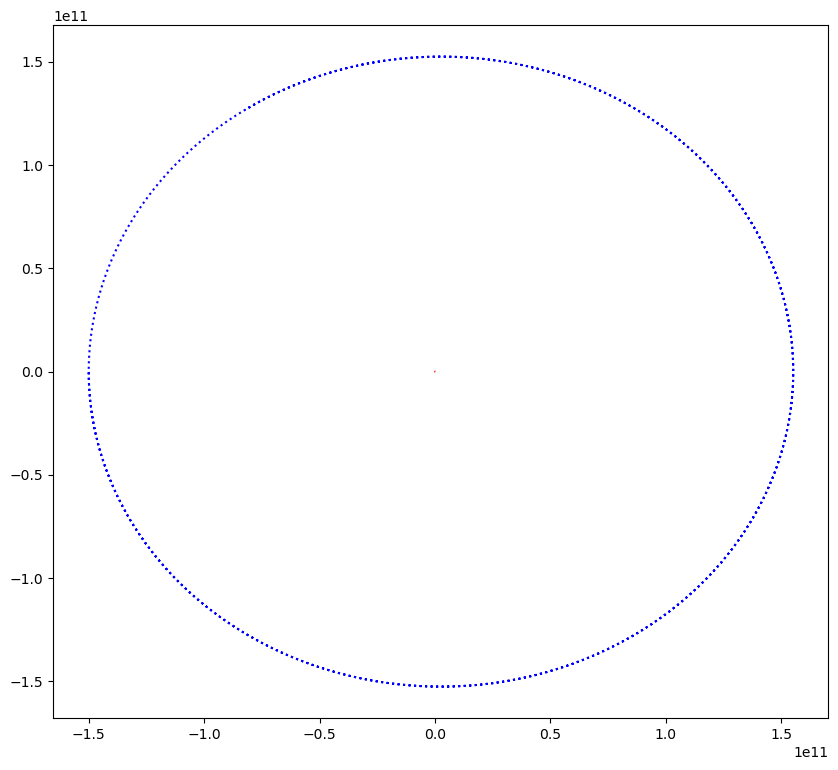

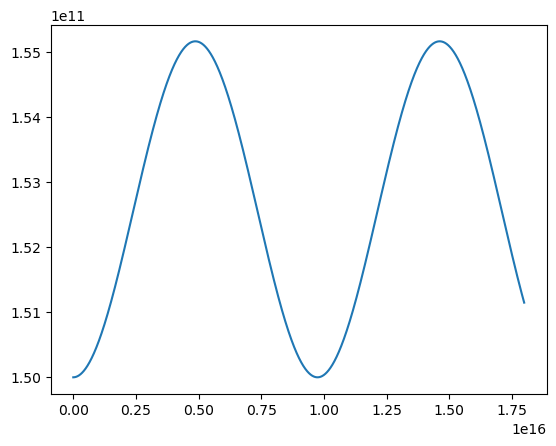

The simulation ran for 60000000.0 seconds


In [124]:
m1 = si_to_geom(5.9722e24)
m2 = si_to_geom(1.989e30)
v1 = np.array([0, -3e4]) / c_SI
v = 5.9722e24 * (3e4) / 1.989e30
v2 = np.array([0, v]) / c_SI
x1_track, y1_track, x2_track, y2_track, t_track, t_count, d = inspiral(m1, m2, v1, v2, 1.5e11, 10000, 60000000)

plt.figure(figsize=(10,9))
plt.plot(x1_track, y1_track, color='blue', linestyle='dotted', alpha=1, label='Particle 1 Path')
plt.plot(x2_track, y2_track, color='red', linestyle='dotted', alpha=1, label='Particle 1 Path')
plt.show()

plt.plot(t_track, d)
plt.show()
print(f"The simulation ran for {t_count} seconds")

In [126]:
def seperation_distance_r(m_1, m_2, e_i, f_gw=10.0):
    numerator = G_SI * (m_1 + m_2)
    denominator = (pi * f_gw * ((1 - e_i**2)**1.5) / ((1 + e_i)**1.1954))**2
    r = (numerator / denominator)**(1/3)
    return r

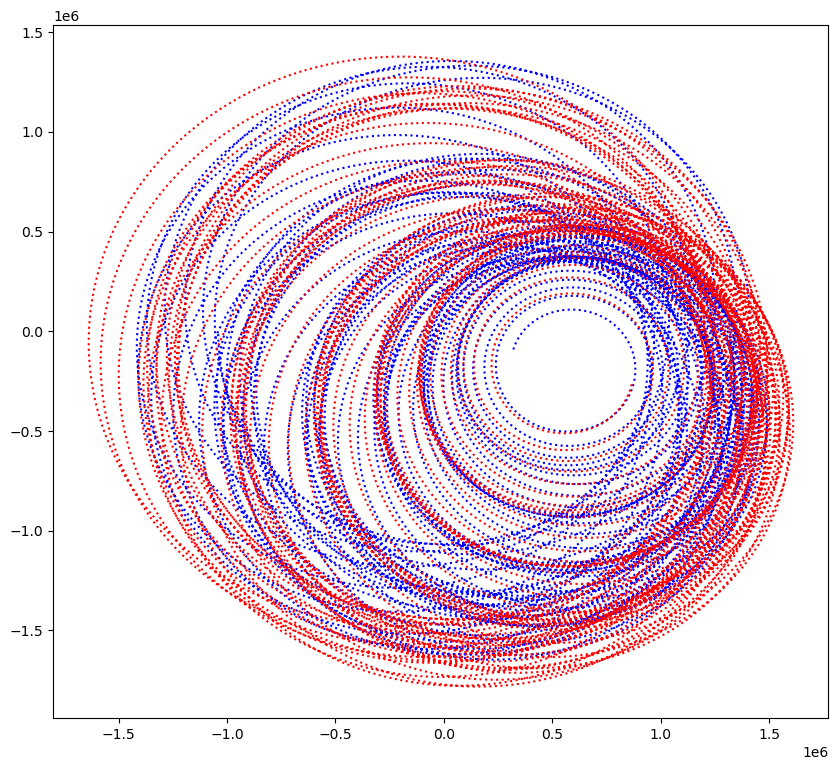

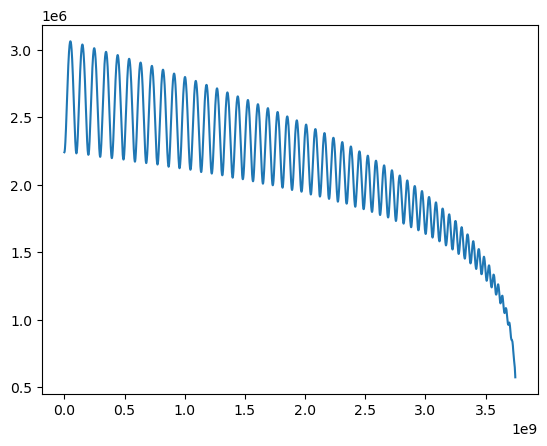

The simulation ran for 12.49850000000496 seconds


In [128]:
solar_mass = 1.989e30
m1 = 34.6*solar_mass
m2 = 30.0*solar_mass
e_i = 0.1
r = seperation_distance_r(m1, m2, e_i, f_gw=10.0)
m1 = si_to_geom(m1)
m2 = si_to_geom(m2)
v = np.sqrt((m1 + m2)/r)
v1 = np.array([0, -v * m2/(m1+m2)])
v2 = np.array([0, v * m1/(m1+m2)])
x1_track, y1_track, x2_track, y2_track, t_track, t_count, d = inspiral(m1, m2, v1, v2, r, 0.0005, 100)

plt.figure(figsize=(10,9))
plt.plot(x1_track, y1_track, color='blue', linestyle='dotted', alpha=1, label='Particle 1 Path')
plt.plot(x2_track, y2_track, color='red', linestyle='dotted', alpha=1, label='Particle 1 Path')
plt.show()

plt.plot(t_track, d)
plt.show()
print(f"The simulation ran for {t_count} seconds")

In [129]:
def bh_simulation(m1, m2, e):
    m1 = m2*solar_mass
    m2 = m2*solar_mass
    e_i = e
    r = seperation_distance_r(m1, m2, e_i, f_gw=10.0)
    m1 = si_to_geom(m1)
    m2 = si_to_geom(m2)
    v = np.sqrt((m1 + m2)/r)
    v1 = np.array([0, -v * m2/(m1+m2)])
    v2 = np.array([0, v * m1/(m1+m2)])
    x1_track, y1_track, x2_track, y2_track, t_track, t_count, d = inspiral(m1, m2, v1, v2, r, 0.0005, 100)
    
    plt.figure(figsize=(10,9))
    plt.plot(x1_track, y1_track, color='blue', linestyle='dotted', alpha=1, label='Particle 1 Path')
    plt.plot(x2_track, y2_track, color='red', linestyle='dotted', alpha=1, label='Particle 1 Path')
    plt.show()
    
    plt.plot(t_track, d)
    plt.show()
    print(f"The simulation ran for {t_count} seconds")

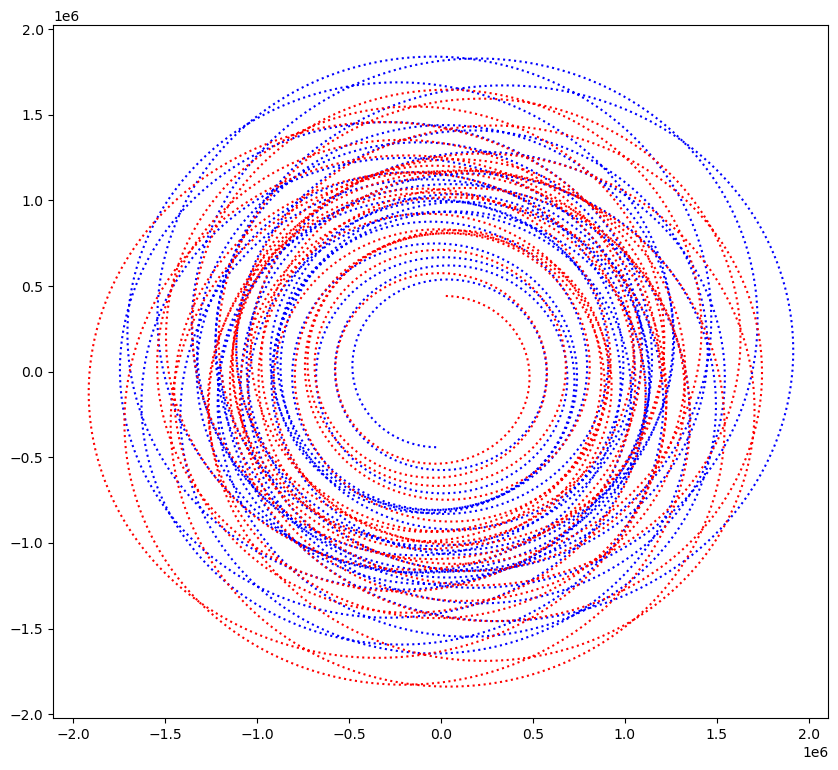

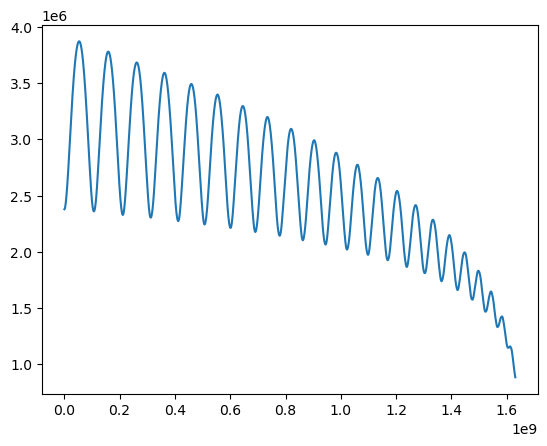

The simulation ran for 5.442000000000651 seconds


In [130]:
bh_simulation(30, 50, 0)

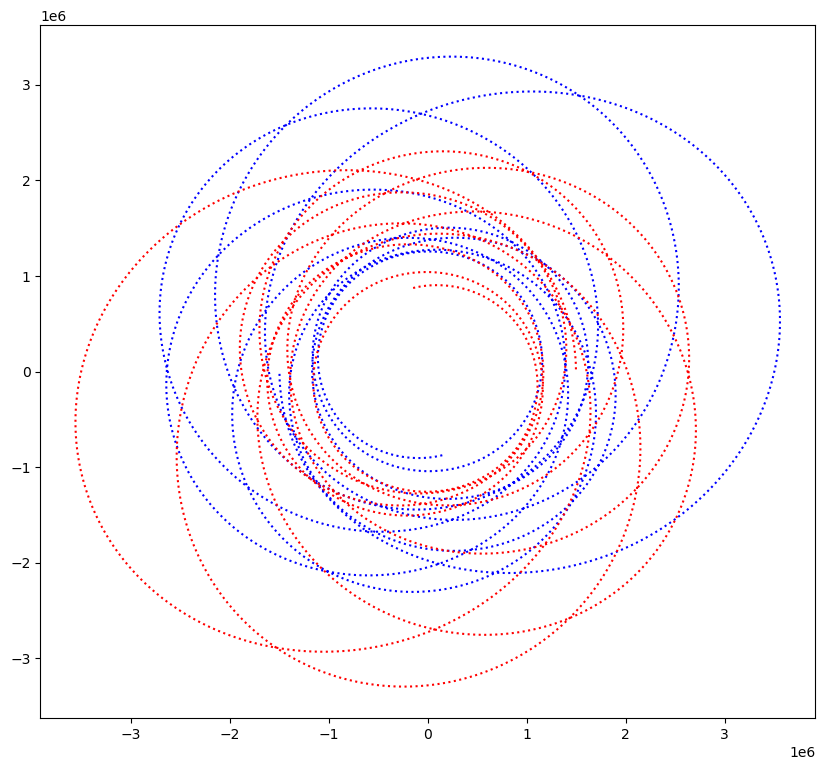

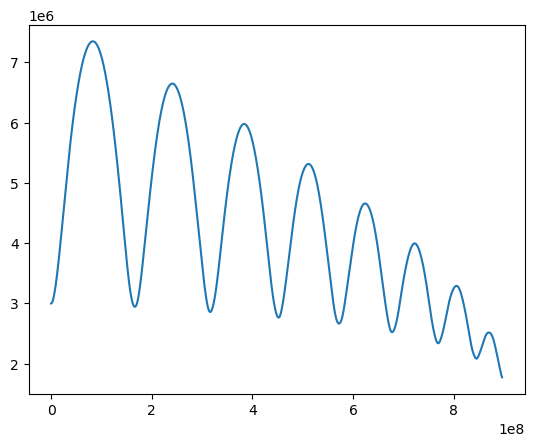

The simulation ran for 2.9884999999996245 seconds


In [140]:
bh_simulation(100, 100, 0)

## Key References
https://www.youtube.com/watch?v=HOWJp8NV5xU

https://doi.org/10.12942/lrr-2002-3

https://fpretori.scholar.princeton.edu/n-body-simulations-introduction

In [142]:
import streamlit as st

In [144]:
m1 = st.slider("Black hole 1 mass: ", 10, 100, 10)
st.write(

2026-09-04 10:34:02.390 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-04 10:34:02.393 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-04 10:34:02.393 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-04 10:34:02.395 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-04 10:34:02.494 
  command:

    streamlit run /opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-09-04 10:34:02.495 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when